<a href="https://colab.research.google.com/github/ShadenAhmed/DataScience-Project/blob/main/DateScience_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Collecting Data
###Phase 1

In [1]:
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:

gold_symbol = "GC=F"
start_date = "2020-01-01"
end_date = "2026-1-31"

gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)

print(gold_raw_data.head()) # first five days of 2020
print(gold_raw_data.tail()) # last available days in 2026

gold_raw_data.to_csv("gold_prices_2020-2026_raw.csv")


/tmp/ipython-input-1443/1211144814.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2020-01-02  1524.500000  1528.699951  1518.000000  1518.099976    214
2020-01-03  1549.199951  1552.699951  1530.099976  1530.099976    107
2020-01-06  1566.199951  1580.000000  1560.400024  1580.000000    416
2020-01-07  1571.800049  1576.300049  1558.300049  1558.300049     47
2020-01-08  1557.400024  1604.199951  1552.300049  1579.699951    236
Price             Close         High          Low         Open  Volume
Ticker             GC=F         GC=F         GC=F         GC=F    GC=F
Date                                                                  
2026-01-26  5079.700195  5095.600098  5052.200195  5081.500000     180
2026-01-27  5079.899902  5079.899902  5079.899902  5079.899902      34
2026-01-28  5301.600098  5301.600098  5301.600098  5301.600098  112054
2026-01-29  53

In [3]:
!pip install gnews

from gnews import GNews
import pandas as pd

google_news = GNews(language='en',
                    start_date=(2020, 1, 1),
                    end_date=(2026, 1, 31))


news_results = google_news.get_news('gold price war conflict geopolitical')

formatted_news = []
for article in news_results:
    formatted_news.append({
        'published_date': article['published date'],
        'title': article['title'],
        'description': article['description'],
        'url': article['url']
    })

df_news = pd.DataFrame(formatted_news)

print(df_news[['published_date', 'title']].head())

df_news.to_csv("raw_gnews_data.csv", index=False)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 24.1 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=7125d567f38c8ae3b6acc9b47b4766f6fe597881ba5d3884ec2aa29ea8dfa501
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
                  published_date  \
0  Sat, 21 Jun 2025 07:00:00 GMT   
1  Wed, 29 Oct 2025 07:00:00 GMT   
2  Wed, 15 Nov 2023 08:00:00 GMT   
3  Wed, 02 Jul 2025 07:00:00 GMT   
4  Tue, 21 Nov 2023 08:00:00 GMT   

                                               title  
0  Gold prices should hit $4,000 as U.S. deficits...  
1  Geopolitics affirms gold as a key strategic as...  
2         The impact of wars on gold prices - 11Onze  
3  How Geopolitical Risk Drives Gold Prices - U.S...  
4  The price of g

#2. Data Processing and Cleaning
###Phase 2


##2.2 Gold prices data


In [16]:
import pandas as pd

df = pd.read_csv("gold_prices_2020-2026_raw.csv")
#Initial Inspection
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1532 entries, 0 to 1531
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1532 non-null   object
 1   Close   1531 non-null   object
 2   High    1531 non-null   object
 3   Low     1531 non-null   object
 4   Open    1531 non-null   object
 5   Volume  1531 non-null   object
dtypes: object(6)
memory usage: 71.9+ KB


,Price,Close,High,Low,Open,Volume
count,1532,1531,1531,1531,1531,1531
unique,1532,1405,1386,1388,1395,883
top,2026-01-30,1815.9000244140625,1813.5,1784.0,1794.300048828125,6
freq,1,4,4,4,4,10


In [17]:
#Renaming Columns
df.rename(columns={'Price': 'Date'}, inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
3,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
4,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416


In [18]:
#Removing Metadata Rows
df = df.iloc[2:].reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
1,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
2,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416
3,2020-01-07,1571.800048828125,1576.300048828125,1558.300048828125,1558.300048828125,47
4,2020-01-08,1557.4000244140625,1604.199951171875,1552.300048828125,1579.699951171875,236


In [19]:
df['Date'] = pd.to_datetime(df['Date'])
#Converting Data Types
numeric_cols = ['Close','High','Low','Open','Volume']
df[numeric_cols] = df[numeric_cols].astype(float)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0


In [20]:
#Removing Duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [21]:
#Sorting by Date
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

In [22]:
#Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161


In [23]:
#Compute daily volatility
df['Volatility'] = df['High'] - df['Low']
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902


In [24]:
#Add new variable (Year) from the Date column
df['Year'] = df['Date'].dt.year
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951,2020
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020


In [25]:
#Handling Missing Values
df.isnull().sum()
df.dropna(inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020
5,2020-01-09,1551.699951,1555.699951,1543.300049,1555.699951,54.0,-0.003660,12.399902,2020


In [26]:
#Outliers analyzing
Q1 = df['Daily_Return'].quantile(0.25)
Q3 = df['Daily_Return'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Daily_Return'] < Q1 - 1.5*IQR) |
              (df['Daily_Return'] > Q3 + 1.5*IQR)]

In [27]:
#Saved cleaned and processed dataset
df.to_csv("gold_prices_cleaned.csv", index=False)


In [28]:
# EXPLORATORY DATA ANALYSIS - GOLD PRICES & GEOPOLITICAL EVENTS
# # 1. INTRODUCTION
# This notebook performs Exploratory Data Analysis (EDA) on gold price data from 2020-2026.
# The goal is to understand patterns, trends, and anomalies in gold prices before integrating
# with geopolitical news data. Key areas of investigation include:
# - Price trends over time
# - Daily returns distribution and patterns
# - Volatility analysis
# - Correlation between different market metrics
# - Identification of extreme events and anomalies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

In [30]:
 #Set professional visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5

print("Libraries imported successfully")



Libraries imported successfully


In [31]:
# Load the cleaned gold dataset
df = pd.read_csv('gold_prices_cleaned.csv')


In [32]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])


In [33]:
# Display basic information
print("="*60)
print("GOLD PRICES DATASET OVERVIEW")
print("="*60)
print(f"\n Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Time Span: {(df['Date'].max() - df['Date'].min()).days} days")
print(f"Years Covered: {sorted(df['Year'].unique())}")

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
df.head()

# %%
print("="*60)
print("DATA TYPES AND MISSING VALUES")
print("="*60)
df.info()

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "No missing values found")

# %%
print("="*60)
print("BASIC STATISTICAL SUMMARY")
print("="*60)
df.describe()

GOLD PRICES DATASET OVERVIEW

 Dataset Shape: 1529 rows, 9 columns
Date Range: 2020-01-03 00:00:00 to 2026-01-30 00:00:00
Time Span: 2219 days
Years Covered: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

FIRST 5 ROWS
DATA TYPES AND MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1529 non-null   datetime64[ns]
 1   Close         1529 non-null   float64       
 2   High          1529 non-null   float64       
 3   Low           1529 non-null   float64       
 4   Open          1529 non-null   float64       
 5   Volume        1529 non-null   float64       
 6   Daily_Return  1529 non-null   float64       
 7   Volatility    1529 non-null   float64       
 8   Year          1529 non-null   int64         
dtypes: datetime64[ns](1), fl

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
count,1529,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000
mean,2023-01-16 00:35:47.285807616,2225.793718,2237.959778,2213.067102,2225.176914,4397.678875,0.000802,24.892676,2022.545455
min,2020-01-03 00:00:00,1477.300049,1484.000000,1452.099976,1469.300049,0.000000,-0.113662,0.000000,2020.000000
25%,2021-07-12 00:00:00,1796.400024,1804.199951,1787.300049,1794.300049,93.000000,-0.004400,10.700073,2021.000000
50%,2023-01-17 00:00:00,1922.099976,1929.400024,1913.699951,1922.599976,295.000000,0.001062,18.599854,2023.000000
75%,2024-07-25 00:00:00,2415.000000,2429.000000,2395.500000,2417.500000,811.000000,0.006822,31.599854,2024.000000
max,2026-01-30 00:00:00,5318.399902,5586.200195,5301.600098,5415.700195,251274.000000,0.059477,740.500000,2026.000000
std,NaN,701.848991,708.633551,695.037235,701.948456,22906.845108,0.011243,30.835723,1.744680


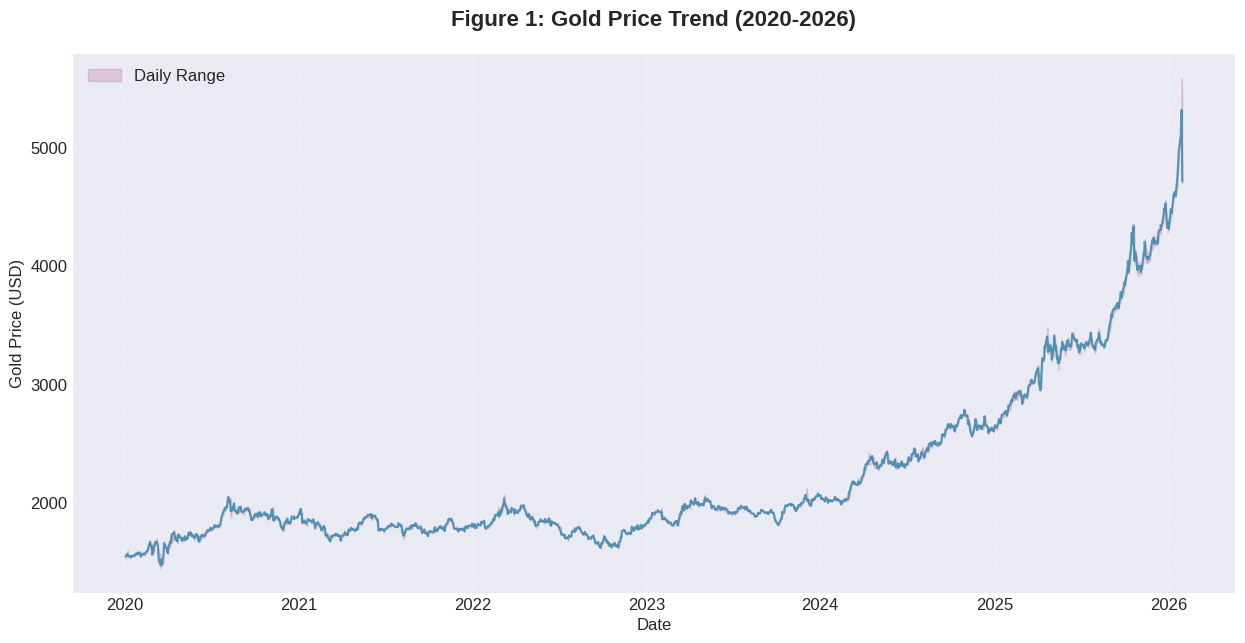

In [34]:
# FIGURE 1: Gold Price Over Time
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(df['Date'], df['Close'], color='#2E86AB', linewidth=1.5, alpha=0.8)
ax.fill_between(df['Date'], df['Low'], df['High'], alpha=0.2, color='#A23B72', label='Daily Range')
ax.set_title('Figure 1: Gold Price Trend (2020-2026)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Gold Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend()